Multicollinearity Detection and Remedy Python Implantation

In [2]:
from sklearn.datasets import fetch_california_housing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = fetch_california_housing()

In [4]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [5]:
df = pd.DataFrame(data.data, columns = data.feature_names)

df["Pice"] = data.target

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Pice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
#multicollinearity>> when one feature is explained by all other features(more than 2)
#when two features>> correlation
#more than two features relationship >> VIF, clustermap

<Axes: >

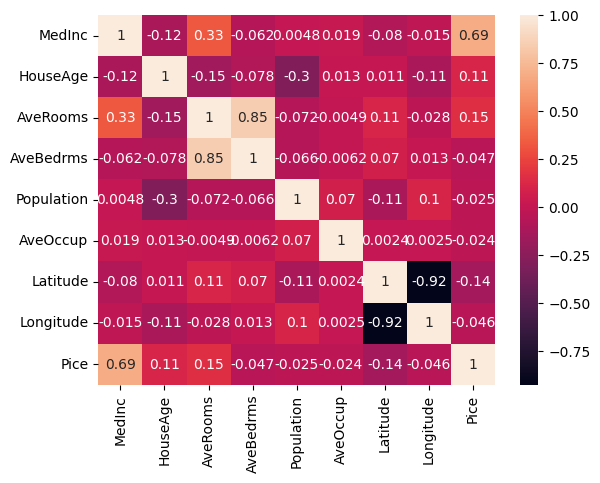

In [8]:
sns.heatmap(df.corr(), annot = True)

In [9]:
# Here we see the corelation b/w the latitude and longitude is about to 92%

<Figure size 500x500 with 0 Axes>

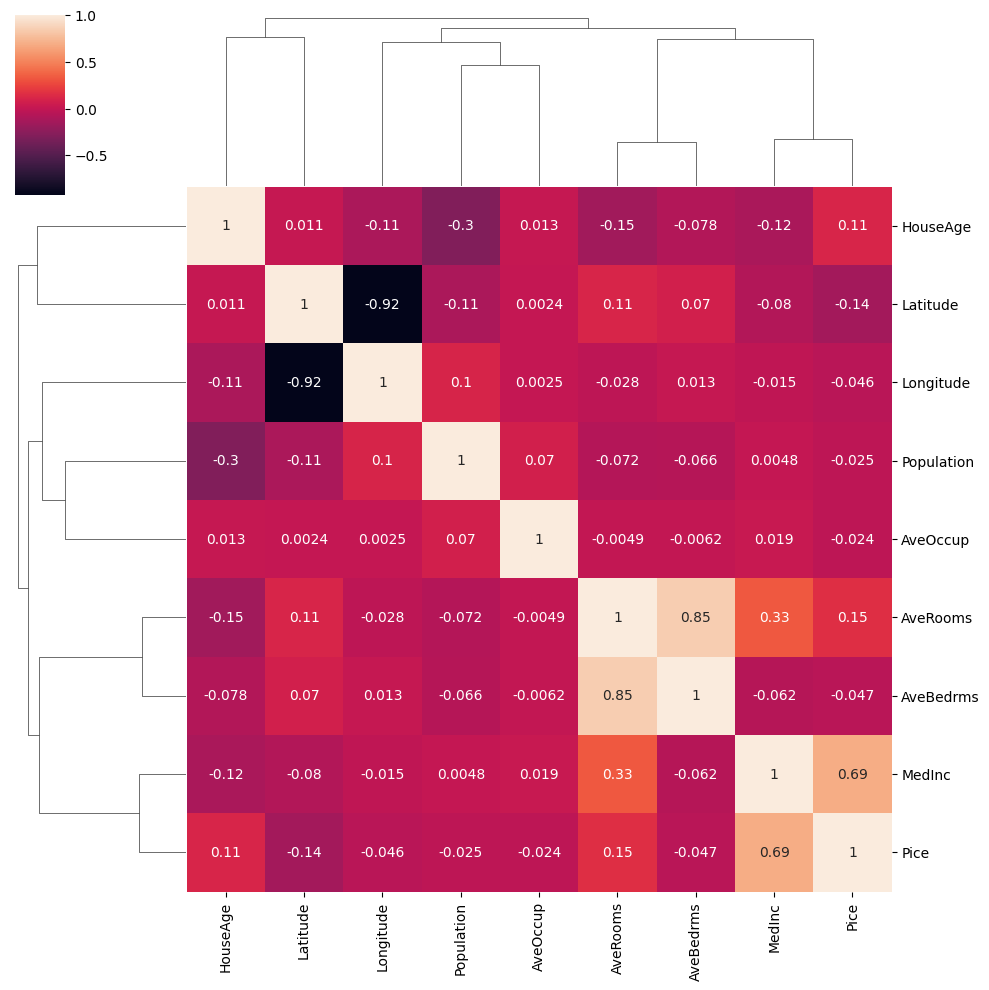

In [10]:
#clustermap shows group(cluster) relationship

plt.figure(figsize = (5,5))
sns.clustermap(df.corr(),annot = True)

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [12]:
vif = pd.DataFrame()
vif["feature"] = df.columns

In [13]:
vif

,feature
0,MedInc
1,HouseAge
2,AveRooms
3,AveBedrms
4,Population
5,AveOccup
6,Latitude
7,Longitude
8,Pice


In [14]:
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]

In [14]:
vif

,feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveRooms,47.956351
3,AveBedrms,45.358192
4,Population,2.936078
5,AveOccup,1.099530
6,Latitude,568.497332
7,Longitude,640.064211
8,Pice,9.285659


In [15]:
df1 = df.copy()

In [16]:
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Pice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [17]:
# now we have to drop the column which is having vif >= 10 on by one

df1.drop("Longitude", axis = 1,inplace =True)

In [18]:
#now again calculating the vif of the remaining data
vif = pd.DataFrame()
vif["feature"] = df1.columns
vif["VIF"]=[variance_inflation_factor(df1.values,i) for i in range(len(df1.columns))]

In [19]:
vif

,feature,VIF
0,MedInc,18.639889
1,HouseAge,7.346583
2,AveRooms,44.714760
3,AveBedrms,42.072000
4,Population,2.796280
5,AveOccup,1.099394
6,Latitude,22.873934
7,Pice,9.193500


In [20]:
#here we see that after dropping a column the vir of all columns changes that why we have to drop it on by one
#again repeating the process

In [21]:
df1.drop("AveRooms", axis =1, inplace = True)

vif = pd.DataFrame()
vif["feature"] = df1.columns
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df1.columns))]

In [22]:
vif

,feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveBedrms,47.956351
3,Population,45.358192
4,AveOccup,2.936078
5,Latitude,1.099530
6,Pice,568.497332


In [23]:
df1.drop("Latitude", axis =1, inplace = True)

vif = pd.DataFrame()
vif["feature"] = df1.columns
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df1.columns))]

In [24]:
vif

,feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveBedrms,47.956351
3,Population,45.358192
4,AveOccup,2.936078
5,Pice,1.099530


In [33]:
#now all the columns have <10 VIR(no multicollinearity) so now we can create the model using remaining data

x =df1.iloc[:, :-1]
y=df1.iloc[:,-1]


In [34]:
from sklearn.model_selection import train_test_split 

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.3, random_state =1)

In [36]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((14448, 5), (6192, 5), (14448,), (6192,))

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
print("The Slope of the data is ",model.coef_)
print("The Intercept of the data is ",model.intercept_)

y_pred = model.predict(x_test)

The Slope of the data is  [ 0.8295202   0.23888438  0.02058888  0.03902186 -0.05185743]
The Intercept of the data is  2.0765314825581394


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
score = r2_score(y_test,y_pred)
print(score)

0.6046846522578225
0.6544937093127864
0.5021661718778507


In [42]:
#adjusted r square
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.5017637843672444

In [43]:
#RFE >> Recursive feature elimination

from sklearn.feature_selection import RFE

In [44]:
X = df.iloc[:, :-1] #independent var
y = df.iloc[:, -1] #dependent variable

In [55]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [56]:
#now using RFE we estimate 5 feature and removing the feature having >10 VIR in a single time

In [57]:
rfe = RFE(estimator = LinearRegression(), n_features_to_select = 5)

In [58]:
rfe.fit(X,y)

,estimator,LinearRegression()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
rfe.predict(X)

array([3.98910415, 4.03191679, 3.44103761, ..., 0.22630645, 0.36574672,
       0.57907858], shape=(20640,))

In [61]:
#now to see which features are selected

In [64]:
rfe.support_  #true for selecting features

array([ True, False,  True,  True, False, False,  True,  True])

In [65]:
rfe.ranking_  # ranking of selected columns

array([1, 2, 1, 1, 4, 3, 1, 1])

Lasso, ridge and elsatic net implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [7]:
df = sns.load_dataset("mpg")

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [9]:
df.drop("name", axis =1,inplace =True)

In [10]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [12]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

In [14]:
df["horsepower"].isnull().sum()

np.int64(0)

In [15]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
dtype: object

In [16]:
df["origin"].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [17]:
df["origin"] = df["origin"].map({"usa":1,"japan":2,"europe":3})

In [18]:
df["origrin"] = df["origin"].astype(int)

In [20]:
df.dtypes  #now whole the data in the numeric form

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
origrin           int64
dtype: object

In [21]:
#seprate x and y

In [26]:
x = df.drop("mpg", axis =1)
y= df["mpg"]

In [27]:
x.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,origrin
0,8,307.0,130.0,3504,12.0,70,1,1
1,8,350.0,165.0,3693,11.5,70,1,1
2,8,318.0,150.0,3436,11.0,70,1,1
3,8,304.0,150.0,3433,12.0,70,1,1
4,8,302.0,140.0,3449,10.5,70,1,1


In [28]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state =1)

In [33]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((278, 8), (120, 8), (278,), (120,))

In [34]:
#Simple Linear regression

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
model = LinearRegression()

In [37]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
for i,col_name in enumerate(x_train.columns):
    print(f"The coefficients for {col_name} is {model.coef_[i]}")

The coefficients for cylinders is -0.3176142302799329
The coefficients for displacement is 0.026237482599079
The coefficients for horsepower is -0.01827076491312457
The coefficients for weight is -0.007487750398361904
The coefficients for acceleration is 0.05040673461971434
The coefficients for model_year is 0.8470951427061371
The coefficients for origin is 0.7595479193987513
The coefficients for origrin is 0.7595479193987522


In [40]:
#The coefficients are relatively smaller , if one independent variable changes slightly there will be not much
#difference in prediction.
#This is sometime is called smoother model

In [41]:
y_pred = model.predict(x_test)

In [44]:
from sklearn.metrics import r2_score
r2_linear = r2_score(y_test,y_pred)

In [51]:
print(f"R-squared score for the linear regression : {r2_linear}")

R-squared score for the linear regression : 0.8348001123742282


#Ridge regression

In [48]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha = 0.1)
ridge_model.fit(x_train,y_train)

for i,col_name in enumerate(x_train.columns):
    print(f"The coefficients for {col_name} is {ridge_model.coef_[i]}")

The coefficients for cylinders is -0.31707405291637
The coefficients for displacement is 0.02622116738017563
The coefficients for horsepower is -0.018268074830448514
The coefficients for weight is -0.007487481562328614
The coefficients for acceleration is 0.05038000639129475
The coefficients for model_year is 0.8470367884094819
The coefficients for origin is 0.7591207466654181
The coefficients for origrin is 0.7591207466650912


In [50]:
#for ridge regression evaluation

y_pred_ridge = ridge_model.predict(x_test)

r2_ridge = r2_score(y_test,y_pred_ridge)
print(f"R-squared score for the ridge regression : {r2_ridge}")

R-squared score for the ridge regression : 0.8348048171905154


In [52]:
# we don not see much variation in coeff of ridge regression as compared to linear regression

#Lasso Regresssion

In [54]:
from sklearn.linear_model import Lasso

In [56]:
lasso_model = Lasso(alpha = 0.5)
lasso_model.fit(x_train,y_train)

for i,col in enumerate(x_train.columns):
    print(f"The coefficient of {col} is {lasso_model.coef_[i]}")

The coefficient of cylinders is -0.0
The coefficient of displacement is 0.006208198888300358
The coefficient of horsepower is -0.011058382987169565
The coefficient of weight is -0.0069826731680230885
The coefficient of acceleration is 0.0
The coefficient of model_year is 0.744654952003819
The coefficient of origin is 0.0
The coefficient of origrin is 0.0


In [57]:
#here we see that the three feature having 0 values means they are least important that we can drop them from the data.
#lasso helps in feature selection

In [59]:
y_pred_lasso = lasso_model.predict(x_test)
r2_lasso = r2_score(y_test,y_pred_lasso)
print(f"R-square for the lasso regression : {r2_lasso}")

R-square for the lasso regression : 0.8277934716635555


In [60]:
#here we see that their is a little bit change in the r2 after dropping the 3 fratures means they are unnecessary

Elastic Net

In [62]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(alpha = 1, l1_ratio = 0.5)

elastic_model.fit(x_train,y_train)

for i,col in enumerate(x_train.columns):
    print(f"The coefficient of {col} is {elastic_model.coef_[i]}")

The coefficient of cylinders is -0.0
The coefficient of displacement is 0.005888869953667563
The coefficient of horsepower is -0.012403874933570126
The coefficient of weight is -0.006934550516257631
The coefficient of acceleration is 0.0
The coefficient of model_year is 0.7133150744603874
The coefficient of origin is 0.0
The coefficient of origrin is 0.0


In [63]:
y_pred_elastic = elastic_model.predict(x_test)
r2_elastic = r2_score(y_test,y_pred_elastic)
print(f"R-square for the ElasticNet regression : {r2_elastic}")


R-square for the ElasticNet regression : 0.8284840073256804


Lasso CV

In [67]:
from sklearn.linear_model import LassoCV
lcvmodel = LassoCV(cv = 5)
lcvmodel.fit(x_train,y_train)
y_pred_lcv = lcvmodel.predict(x_test)

score = r2_score(y_test,y_pred_lcv)
print("R2 Score", score)

R2 Score 0.8082805983844751


Ridge CV

In [73]:
from sklearn.linear_model import RidgeCV
rcvmodel = RidgeCV(cv = 5)
rcvmodel.fit(x_train,y_train)
y_pred_rcv = rcvmodel.predict(x_test)

score = r2_score(y_test,y_pred_rcv)
print("R2 Score", score)

R2 Score 0.8352028560513514


In [75]:
rcvmodel.get_params() #gives parameter 

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

ElasticNet CV

In [76]:
from sklearn.linear_model import ElasticNetCV
encvmodel = ElasticNetCV(cv = 5)
encvmodel.fit(x_train,y_train)
y_pred_encv = encvmodel.predict(x_test)

score = r2_score(y_test,y_pred_encv)
print("R2 Score", score)

R2 Score 0.792863401804916


Logistic Regression - 1

In [11]:
from sklearn.datasets import load_iris

In [13]:
data = load_iris()

In [14]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [17]:
df = pd.DataFrame(data.data, columns = data.feature_names )
df["target"] = data.target

In [19]:
df                                                               #Balanced dataset 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [20]:
df.target.unique()

array([0, 1, 2])

In [ ]:
#since there are 3 variable and today we are dealing with binary classification so we have to drop a classification here we drop 2  

In [21]:
#for binary classification

In [25]:
df1 = df[df["target"] !=2]

In [26]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


In [27]:
df1.target.unique()

array([0, 1])

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x = df1.iloc[:,:-1]
y = df1.iloc[:,-1]

In [30]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [31]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state =1)

In [33]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((80, 4), (20, 4), (80,), (20,))

In [34]:
# Model Training

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred = model.predict(x_test)

In [39]:
y_pred

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0])

In [40]:
y_pred_prob = model.predict_proba(x_test)

In [42]:
y_pred_prob   #correspnding to higher probabily class is predicted, cutoff 0.5

array([[0.04043262, 0.95956738],
       [0.01046123, 0.98953877],
       [0.98706759, 0.01293241],
       [0.05440516, 0.94559484],
       [0.1383348 , 0.8616652 ],
       [0.97966131, 0.02033869],
       [0.98204504, 0.01795496],
       [0.03292232, 0.96707768],
       [0.03380573, 0.96619427],
       [0.00850516, 0.99149484],
       [0.02466034, 0.97533966],
       [0.97515854, 0.02484146],
       [0.00517837, 0.99482163],
       [0.00238366, 0.99761634],
       [0.0077453 , 0.9922547 ],
       [0.98619342, 0.01380658],
       [0.96597536, 0.03402464],
       [0.94907826, 0.05092174],
       [0.00735493, 0.99264507],
       [0.97742977, 0.02257023]])

In [43]:
#Evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [44]:
print(confusion_matrix(y_test,y_pred))

[[ 8  0]
 [ 0 12]]


In [45]:
print(accuracy_score(y_test,y_pred))

1.0


In [47]:
print(classification_report(y_test,y_pred))

#first two rows, 0 and 1>> precision, recall, f1 score and no of data point of respective class
#macro avg>> for each calss take simple avg>> avg precison of class 0 and class 1 will be macro avg
#similarly for recall, f1 score, support
#weighted avg is used in case of class imbalance., it gives importance to performance on dominant class

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [48]:
#Now We illustrating the ROC-AUC

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob1 = model.predict_proba(x_test)[:,1] #this will return the probability of the class 1 by which class 0 propability automatically fetched

In [52]:
fpr,tpr,thresholds = roc_curve(y_test,y_pred_prob1)

In [53]:
print(fpr)
print(tpr)
print(thresholds)

[0. 0. 0. 1.]
[0.         0.08333333 1.         1.        ]
[       inf 0.99761634 0.8616652  0.01293241]


In [54]:
#seeing the area under the curve
auc(fpr,tpr)

1.0

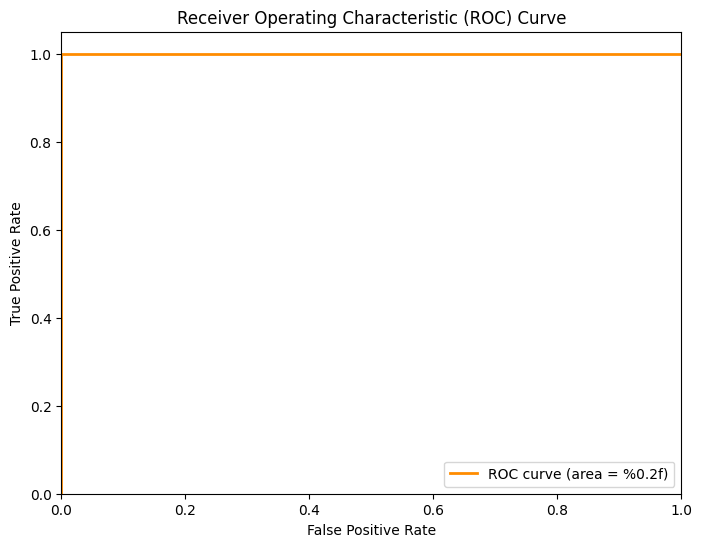

In [57]:
#plotting the roc-auc curve (FPR vs TPR)

plt.figure(figsize=(8, 6))  # Create a new figure with a specified size
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label='ROC curve (area = %0.2f)')  # Plot ROC curve,
plt.xlim([0.0, 1.0])  # Set x-axis limits
plt.ylim([0.0, 1.05])  # Set y-axis limits
plt.xlabel('False Positive Rate')  # Set x-axis label
plt.ylabel('True Positive Rate')  # Set y-axis label
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Set plot title
plt.legend(loc="lower right")  # Add legend to the plot
plt.show()  # Show the plot

In [58]:
#cross validation>>n two ways. ist>>LogisticRegressionCV or 2. Use Kfold
#as h/w LogisticRegressionCV, now Kfold
from sklearn.linear_model import LogisticRegressionCV

In [59]:
from sklearn.model_selection import KFold

In [70]:
kfmodel = KFold(n_splits = 5)
# shuffle : bool, default=False
# Whether to shuffle the data before splitting into batches.
# Note that the samples within each split will not be shuffled.

In [71]:
kfmodel

KFold(n_splits=5, random_state=None, shuffle=False)

In [73]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x_train, y_train, cv = kfmodel, scoring = "accuracy")

In [74]:
scores

array([1., 1., 1., 1., 1.])

In [75]:
np.mean(scores)

np.float64(1.0)

Logistic regression implementation - 2

In [98]:
from sklearn.datasets import make_classification  #Now we are making our own data
from sklearn.linear_model import LogisticRegression

In [99]:
x,y = make_classification(n_samples = 1000, n_features=10, n_redundant =5, n_informative=5, n_classes=2, random_state=1)

In [100]:
x

array([[ 2.56999479, -0.13019997,  3.16075093, ..., -1.93094078,
         3.26130366,  2.05692145],
       [ 0.34129317,  2.51321418, -0.80416572, ...,  6.24734437,
        -1.92769365,  2.9503149 ],
       [ 2.27539972,  3.36561455,  0.17164362, ...,  2.74693781,
         0.13492444,  2.00339547],
       ...,
       [ 0.5234359 ,  1.90466429,  0.93243365, ...,  1.53945231,
         1.90646166,  1.99458587],
       [ 1.33747921,  3.25859684,  0.78792366, ...,  5.18788314,
        -0.82071083,  3.51411431],
       [-0.98534299,  0.83919047,  2.5820803 , ...,  3.04705685,
         0.66885641,  3.32838496]], shape=(1000, 10))

In [101]:
y

array([1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,

In [102]:
from sklearn.model_selection import train_test_split 

In [103]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state=1)

In [104]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((700, 10), (300, 10), (700,), (300,))

In [105]:
model = LogisticRegression()

In [106]:
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)

In [107]:
y_pred

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [108]:
#evaluation Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[129  13]
 [ 34 124]]
0.8433333333333334
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       142
           1       0.91      0.78      0.84       158

    accuracy                           0.84       300
   macro avg       0.85      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300



In [111]:
from sklearn.metrics import roc_curve, auc
y_pred_prob1 = model.predict_proba(x_test)[:,-1]


In [112]:
fpr,tpr,thresholds = roc_curve(y_test,y_pred_prob1)

In [115]:
auc_score = auc(fpr,tpr)
auc_score

0.8849170975218399

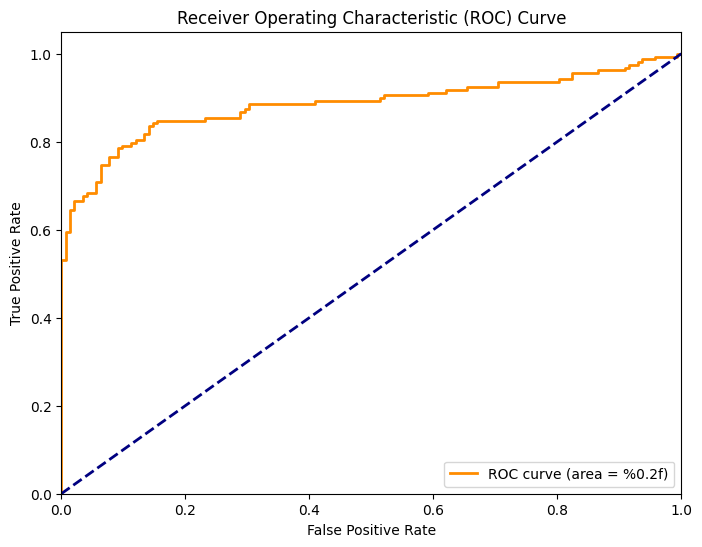

In [117]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label='ROC curve (area = %0.2f)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [118]:
#precision,recall,accuracy tradeoff to decide optimal threshold
#by default sklean 0.5 uses as threshold  , here we are manually geting the threshold

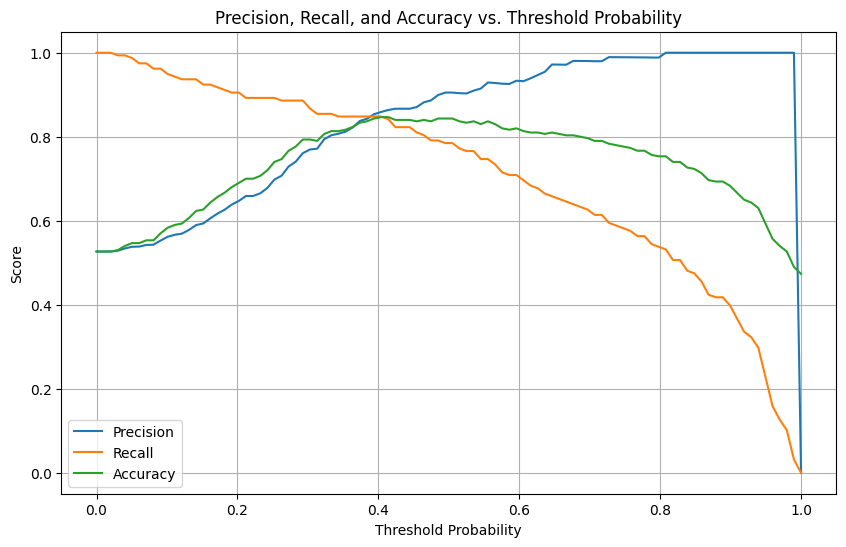

In [121]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Calculate precision, recall, and accuracy for different threshold probabilities
thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []
accuracies = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob1 >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precisions.append(precision)
    recalls.append(recall)
    accuracies.append(accuracy)

# Plot precision, recall, and accuracy against threshold probabilities
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, accuracies, label='Accuracy')
plt.xlabel('Threshold Probability')
plt.ylabel('Score')
plt.title('Precision, Recall, and Accuracy vs. Threshold Probability')
plt.legend()
plt.grid(True)
plt.show()

In [125]:
#observation>> cutoff =0.4

In [126]:
new_y_pred_prob = np.where(y_pred_prob > 0.4,1,0)

In [129]:
print(y_pred_prob , new_y_pred_prob)

[[0.01925457 0.98074543]
 [0.8369654  0.1630346 ]
 [0.71163174 0.28836826]
 [0.86595477 0.13404523]
 [0.44881263 0.55118737]
 [0.906619   0.093381  ]
 [0.03803546 0.96196454]
 [0.69878052 0.30121948]
 [0.87649197 0.12350803]
 [0.04268774 0.95731226]
 [0.91221239 0.08778761]
 [0.57950286 0.42049714]
 [0.27686074 0.72313926]
 [0.76744489 0.23255511]
 [0.41878562 0.58121438]
 [0.33162756 0.66837244]
 [0.05094872 0.94905128]
 [0.14027377 0.85972623]
 [0.02937625 0.97062375]
 [0.92765479 0.07234521]
 [0.55017835 0.44982165]
 [0.04323274 0.95676726]
 [0.18990573 0.81009427]
 [0.89966296 0.10033704]
 [0.09082865 0.90917135]
 [0.44410569 0.55589431]
 [0.85854528 0.14145472]
 [0.5383565  0.4616435 ]
 [0.49035344 0.50964656]
 [0.82655524 0.17344476]
 [0.75068502 0.24931498]
 [0.23985245 0.76014755]
 [0.90011396 0.09988604]
 [0.35887485 0.64112515]
 [0.04116137 0.95883863]
 [0.0219789  0.9780211 ]
 [0.01199349 0.98800651]
 [0.9456352  0.0543648 ]
 [0.96564211 0.03435789]
 [0.53858522 0.46141478]


In [130]:
#cross validation

In [131]:
from sklearn.model_selection import KFold
kfmodel = KFold(n_splits = 5)

In [133]:
from sklearn.model_selection import cross_val_score
acc = cross_val_score(model, x_train, y_train, cv = kfmodel)

In [134]:
acc

array([0.78571429, 0.79285714, 0.8       , 0.84285714, 0.8       ])

In [135]:
np.mean(acc)

np.float64(0.8042857142857143)

.

 Logistic regression implementation with hyperparameter

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
x, y = make_classification(n_samples = 1000, n_features=10, n_redundant =5, n_informative=5, n_classes=2, random_state=1)

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=1)

In [ ]:
#hyperparameter tuning
#GridSearchCV

In [6]:
from sklearn.model_selection import GridSearchCV

In [10]:
parameter = {"penalty" : ("l1","l2","elasticnet"), "C" : [1,2,3,4,5,6]}  #18 combination

In [8]:
classifier = LogisticRegression()

In [9]:
classifier

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
#now using gridsearchcv we get the best parameter

clf = GridSearchCV(classifier, param_grid = parameter, cv = 5)

In [12]:
clf

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 2, ...], 'penalty': ('l1', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [13]:
clf.fit(x_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 2, ...], 'penalty': ('l1', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [15]:
clf.best_params_ #these are the best parameter for the model 

{'C': 1, 'penalty': 'l2'}

In [16]:
clf.best_score_

np.float64(0.8042857142857145)

In [17]:
model  = LogisticRegression(C = 1,penalty = "l2")
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
y_pred_grid = model.predict(x_test)

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred_grid))
print(accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))

[[129  13]
 [ 34 124]]
0.8433333333333334
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       142
           1       0.91      0.78      0.84       158

    accuracy                           0.84       300
   macro avg       0.85      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300



In [21]:
#randomized search cv, it will take randomly some combination

In [23]:
from sklearn.model_selection import RandomizedSearchCV
randomized_clf = RandomizedSearchCV(classifier, param_distributions = parameter, cv =5, n_iter=10)

In [24]:
randomized_clf.fit(x_train,y_train)

,estimator,LogisticRegression()
,param_distributions,"{'C': [1, 2, ...], 'penalty': ('l1', ...)}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [26]:
randomized_clf.best_params_    #these are the best parameter for the model

{'penalty': 'l2', 'C': 1}

In [27]:
randomized_clf.best_score_

np.float64(0.8042857142857145)

In [28]:
model = LogisticRegression(C = 1, penalty = "l2")
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred_randomised = model.predict(x_test)

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred_randomised))
print(accuracy_score(y_test, y_pred_randomised))
print(classification_report(y_test, y_pred_randomised))

[[129  13]
 [ 34 124]]
0.8433333333333334
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       142
           1       0.91      0.78      0.84       158

    accuracy                           0.84       300
   macro avg       0.85      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300



.

Multiclass Classification implementation

In [2]:
#OVR
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

In [3]:
x,y = make_classification(n_samples = 1000, n_features=10, n_redundant =5, n_informative=5, n_classes=3, random_state=1)

In [4]:
x

array([[ 1.89149379, -0.39847585,  1.63856893, ...,  0.58810926,
        -0.02542177, -0.52835426],
       [ 1.86913773, -0.56336215,  2.03411807, ..., -0.55633   ,
        -0.27340013,  0.72129251],
       [ 1.95259701, -2.83144572,  0.19055535, ..., -0.60957741,
        -2.07750191, -1.75469982],
       ...,
       [ 1.98033054,  1.37228804,  1.67376262, ...,  2.75687956,
        -0.20719842,  0.39299534],
       [-1.54305631, -0.27530218,  0.38744703, ...,  0.72769107,
         0.51983329, -1.92306657],
       [ 1.17970389, -3.3812155 , -0.1498426 , ...,  1.24640268,
        -4.00356845, -3.01027048]], shape=(1000, 10))

In [5]:
y

array([1, 0, 1, 2, 0, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 1, 1, 0, 1, 0, 2, 0,
       2, 2, 0, 0, 2, 0, 1, 1, 2, 1, 0, 2, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 1,
       1, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 0, 1, 2, 2, 2,
       0, 1, 0, 2, 1, 0, 2, 1, 1, 2, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2, 2, 2,
       1, 2, 0, 2, 0, 0, 0, 0, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 0, 1,
       0, 0, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 0, 1, 2, 0, 2, 1, 2, 0, 0, 1,
       0, 0, 2, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 0, 2, 1, 0, 0, 0, 0, 0, 0,
       2, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 0, 2, 1, 1, 0,
       1, 1, 1, 1, 2, 1, 0, 2, 2, 1, 2, 1, 1, 2, 0, 0, 0, 2, 2, 2, 0, 2,
       0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 1, 0, 1, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 2,
       1, 2, 1, 2, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 1, 0, 0, 1, 1, 1,
       1, 2, 1, 2, 2, 2, 1, 0, 0, 1, 0, 0, 2, 1, 1,

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state = 1)

In [7]:
model = LogisticRegression(multi_class = "ovr", solver = "lbfgs")

In [8]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [9]:
y_pred = model.predict(x_test)

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[75 21  3]
 [10 58 21]
 [23 14 75]]
0.6933333333333334
              precision    recall  f1-score   support

           0       0.69      0.76      0.72        99
           1       0.62      0.65      0.64        89
           2       0.76      0.67      0.71       112

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.70      0.69      0.69       300



In [11]:
#Multinomial

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state=1)
model = LogisticRegression(multi_class='multinomial', solver = 'lbfgs')
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [14]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [15]:
y_pred = model.predict(x_test)

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[70 21  8]
 [13 57 19]
 [21 13 78]]
0.6833333333333333
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        99
           1       0.63      0.64      0.63        89
           2       0.74      0.70      0.72       112

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.69      0.68      0.68       300



Multiclass Classification iris implementation

In [24]:
from sklearn.datasets import load_iris

In [25]:
data = load_iris()

In [26]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [33]:
df = pd.DataFrame(data.data, columns = data["feature_names"])
df["target"] = data.target

In [35]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [37]:
x = df.iloc[:,:-1]
y= df.iloc[:,-1]

In [38]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [39]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state = 1)

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model = LogisticRegression(max_iter = 300)

In [46]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [47]:
y_pred = model.predict(x_test)

In [48]:
#Evaluation Matrix

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [50]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[14  0  0]
 [ 0 17  1]
 [ 0  0 13]]
0.9777777777777777
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        18
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [51]:
#roc auc score can only be calculated for binary classification